# 04 - Red Neuronal con scikit-learn

En este notebook se implementa una segunda red neuronal tipo perceptrón multicapa utilizando la librería scikit-learn. Esto permite cumplir con el requisito de implementar redes neuronales usando dos librerías diferentes: Keras y scikit-learn.

Para mantener consistencia con el modelo anterior, se utiliza el mismo conjunto de datos procesado en el Notebook 02.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)

SEED = 42
np.random.seed(SEED)

Se importan las librerías necesarias para entrenar y evaluar una red neuronal con scikit-learn. En este caso se utilizará `MLPClassifier`, que corresponde a un perceptrón multicapa para problemas de clasificación. También se fija una semilla aleatoria para garantizar reproducibilidad.

In [10]:
#Cargar datos procesados
X_train_p = joblib.load('modelo_final/X_train_p.pkl')
X_val_p = joblib.load('modelo_final/X_val_p.pkl')
X_test_p = joblib.load('modelo_final/X_test_p.pkl')

y_train = joblib.load('modelo_final/y_train.pkl')
y_val = joblib.load('modelo_final/y_val.pkl')
y_test = joblib.load('modelo_final/y_test.pkl')

print("Train:", X_train_p.shape)
print("Validation:", X_val_p.shape)
print("Test:", X_test_p.shape)

Train: (5088, 49)
Validation: (898, 49)
Test: (1057, 49)


Los datos utilizados en este notebook ya fueron transformados previamente en el Notebook 02. Esto significa que ya se realizó el tratamiento de valores perdidos, codificación de variables categóricas, escalamiento de variables numéricas, partición train/validation/test y control de data leakage. Al cargar estos archivos procesados se evita duplicar código y se asegura que ambos modelos trabajen con la misma base de comparación.]

### Modelo base scikit-learn

#Modelo base scikit-learn
mlp_base = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=32,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=SEED
)

mlp_base.fit(X_train_p, y_train)

Se construye un modelo base con `MLPClassifier`. La arquitectura considera dos capas ocultas de 64 y 32 neuronas, función de activación ReLU y optimizador Adam. El parámetro `alpha` representa la regularización L2, mientras que `early_stopping=True` permite detener el entrenamiento si el modelo deja de mejorar durante la validación interna. Este modelo sirve como segunda implementación de red neuronal, usando una librería distinta a Keras.

### Evaluación del modelo base

In [13]:
y_proba_base_sklearn = mlp_base.predict_proba(X_test_p)[:, 1]
y_pred_base_sklearn = mlp_base.predict(X_test_p)

acc_base_sklearn = accuracy_score(y_test, y_pred_base_sklearn)
f1_base_sklearn = f1_score(y_test, y_pred_base_sklearn)
roc_auc_base_sklearn = roc_auc_score(y_test, y_proba_base_sklearn)

print("="*60)
print("RESULTADOS MODELO BASE - MLPClassifier")
print("="*60)

print(f"Accuracy : {acc_base_sklearn:.4f}")
print(f"F1-score : {f1_base_sklearn:.4f}")
print(f"ROC-AUC  : {roc_auc_base_sklearn:.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_base_sklearn))

cm_base_sklearn = confusion_matrix(y_test, y_pred_base_sklearn)

print("\nMatriz de confusión:")
print(cm_base_sklearn)

RESULTADOS MODELO BASE - MLPClassifier
Accuracy : 0.7975
F1-score : 0.5615
ROC-AUC  : 0.8459

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       777
           1       0.66      0.49      0.56       280

    accuracy                           0.80      1057
   macro avg       0.75      0.70      0.71      1057
weighted avg       0.79      0.80      0.79      1057


Matriz de confusión:
[[706  71]
 [143 137]]


La evaluación del modelo se realiza sobre el conjunto de prueba, que no fue utilizado durante el entrenamiento. Se reportan las métricas Accuracy, F1-score y ROC-AUC. Accuracy mide la proporción total de aciertos, F1-score resume el equilibrio entre precisión y recall para la clase churn, y ROC-AUC evalúa la capacidad del modelo para diferenciar clientes que abandonan de aquellos que permanecen.

### GRAFICOS MODELO BASE MLPClassifier

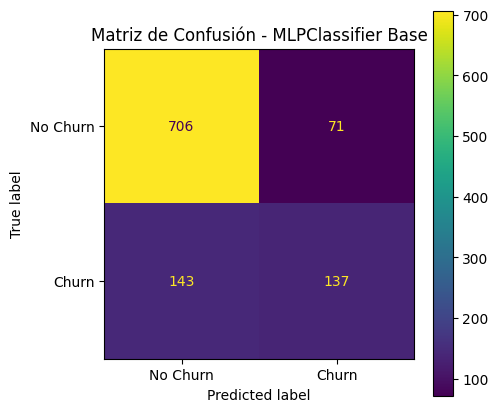

In [27]:
 
fig, ax = plt.subplots(figsize=(5,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_base_sklearn,
    display_labels=['No Churn', 'Churn']
)

disp.plot(ax=ax)
plt.title('Matriz de Confusión - MLPClassifier Base')

plt.figtext(
    0.5,
    -0.08,
    "",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

La matriz de confusión permite identificar cuántos clientes fueron clasificados correctamente y cuántos fueron clasificados de forma incorrecta. En este problema, los falsos negativos son especialmente relevantes, ya que representan clientes que sí abandonaron el servicio pero que el modelo no logró detectar como churn.

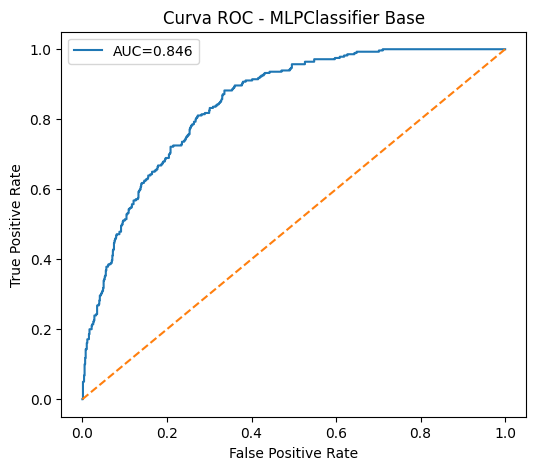

In [26]:
fpr_base_sklearn, tpr_base_sklearn, _ = roc_curve(
    y_test,
    y_proba_base_sklearn
)

plt.figure(figsize=(6,5))
plt.plot(
    fpr_base_sklearn,
    tpr_base_sklearn,
    label=f'AUC={roc_auc_base_sklearn:.3f}'
)
plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - MLPClassifier Base')
plt.legend()

plt.figtext(
    0.5,
    -0.08,
    
    "",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

La curva ROC evalúa la capacidad del modelo para separar clientes con churn y sin churn en distintos umbrales. Mientras más alejada se encuentre la curva de la diagonal, mejor es la capacidad para distinguir entre clientes con churn y sin churn

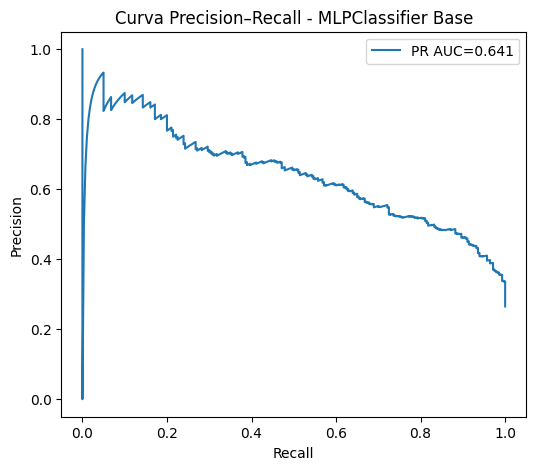

In [25]:
precision_base_sklearn, recall_base_sklearn, _ = precision_recall_curve(
    y_test,
    y_proba_base_sklearn
)

pr_auc_base_sklearn = auc(
    recall_base_sklearn,
    precision_base_sklearn
)

plt.figure(figsize=(6,5))
plt.plot(
    recall_base_sklearn,
    precision_base_sklearn,
    label=f'PR AUC={pr_auc_base_sklearn:.3f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision–Recall - MLPClassifier Base')
plt.legend()

plt.figtext(
    0.5,
    -0.08,
    "",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

La curva Precision–Recall es útil en problemas donde existe desbalance entre clases. En el caso de churn, normalmente hay más clientes que permanecen que clientes que abandonan. Por ello, esta curva permite evaluar mejor el desempeño del modelo sobre la clase de interés, que en este caso es el abandono.

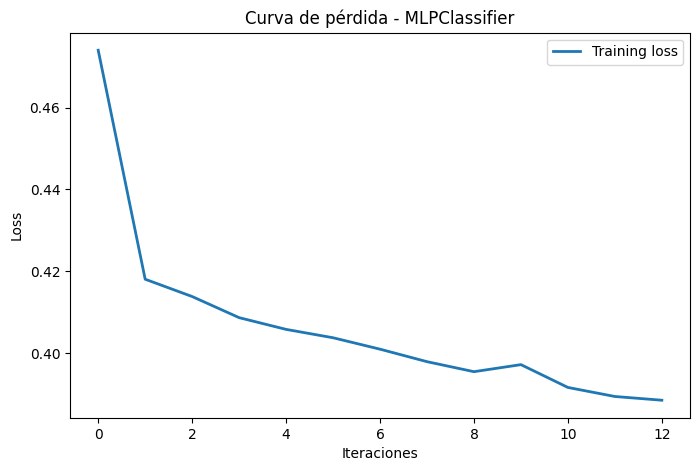

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    mlp_base.loss_curve_,
    label='Training loss',
    linewidth=2
)

plt.title('Curva de pérdida - MLPClassifier')
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.legend()

plt.figtext(
    0.5,
    -0.08,
    "",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

La curva de pérdida muestra cómo evoluciona el error del modelo durante el entrenamiento. Una disminución progresiva de la pérdida indica que la red neuronal está aprendiendo patrones presentes en los datos. Si la pérdida se estabiliza, significa que el modelo llegó a un punto donde las mejoras adicionales son reducidas.

# Tuning básico del modelo scikit-learn


In [32]:
param_grid_sklearn = [
    {
        'hidden_layer_sizes': (64, 32),
        'activation': 'relu',
        'alpha': 0.0001,
        'learning_rate_init': 0.001,
        'batch_size': 32
    },
    {
        'hidden_layer_sizes': (128, 64),
        'activation': 'relu',
        'alpha': 0.001,
        'learning_rate_init': 0.001,
        'batch_size': 32
    },
    {
        'hidden_layer_sizes': (128, 64, 32),
        'activation': 'relu',
        'alpha': 0.001,
        'learning_rate_init': 0.0005,
        'batch_size': 16
    },
    {
        'hidden_layer_sizes': (64, 32),
        'activation': 'tanh',
        'alpha': 0.001,
        'learning_rate_init': 0.001,
        'batch_size': 32
    }
]

results_sklearn = []

for i, params in enumerate(param_grid_sklearn, start=1):
    print(f"\nEntrenando configuración {i}")
    print(params)

    temp_model = MLPClassifier(
        hidden_layer_sizes=params['hidden_layer_sizes'],
        activation=params['activation'],
        solver='adam',
        alpha=params['alpha'],
        batch_size=params['batch_size'],
        learning_rate_init=params['learning_rate_init'],
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        random_state=SEED
    )

    temp_model.fit(X_train_p, y_train)

    val_proba = temp_model.predict_proba(X_val_p)[:, 1]
    val_pred = temp_model.predict(X_val_p)

    results_sklearn.append({
        **params,
        'val_accuracy': accuracy_score(y_val, val_pred),
        'val_f1': f1_score(y_val, val_pred),
        'val_auc': roc_auc_score(y_val, val_proba),
        'iterations': temp_model.n_iter_
    })

results_sklearn_df = pd.DataFrame(results_sklearn)
results_sklearn_df.sort_values(by='val_auc', ascending=False)


Entrenando configuración 1
{'hidden_layer_sizes': (64, 32), 'activation': 'relu', 'alpha': 0.0001, 'learning_rate_init': 0.001, 'batch_size': 32}

Entrenando configuración 2
{'hidden_layer_sizes': (128, 64), 'activation': 'relu', 'alpha': 0.001, 'learning_rate_init': 0.001, 'batch_size': 32}

Entrenando configuración 3
{'hidden_layer_sizes': (128, 64, 32), 'activation': 'relu', 'alpha': 0.001, 'learning_rate_init': 0.0005, 'batch_size': 16}

Entrenando configuración 4
{'hidden_layer_sizes': (64, 32), 'activation': 'tanh', 'alpha': 0.001, 'learning_rate_init': 0.001, 'batch_size': 32}


,hidden_layer_sizes,activation,alpha,learning_rate_init,batch_size,val_accuracy,val_f1,val_auc,iterations
2,"(128, 64, 32)",relu,0.0010,0.0005,16,0.799555,0.505495,0.838929,18
0,"(64, 32)",relu,0.0001,0.0010,32,0.810690,0.572864,0.838140,13
1,"(128, 64)",relu,0.0010,0.0010,32,0.814031,0.579345,0.836905,14
3,"(64, 32)",tanh,0.0010,0.0010,32,0.799555,0.585253,0.835899,15


Se realizó un tuning básico del modelo `MLPClassifier`, evaluando distintas arquitecturas de capas ocultas, funciones de activación, regularización L2 mediante `alpha`, learning rate y batch size. La selección del mejor modelo se realiza usando el ROC-AUC en el conjunto de validación, manteniendo la misma lógica aplicada en el modelo Keras.

### Mejor configuración


In [33]:
best_params_sklearn = results_sklearn_df.sort_values(
    by='val_auc',
    ascending=False
).iloc[0].to_dict()

best_params_sklearn

{'hidden_layer_sizes': (128, 64, 32),
 'activation': 'relu',
 'alpha': 0.001,
 'learning_rate_init': 0.0005,
 'batch_size': 16,
 'val_accuracy': 0.799554565701559,
 'val_f1': 0.5054945054945055,
 'val_auc': 0.838929208046855,
 'iterations': 18}

### Entrenar modelo final scikit-learn


In [37]:
mlp_final = MLPClassifier(
    hidden_layer_sizes=best_params_sklearn['hidden_layer_sizes'],
    activation=best_params_sklearn['activation'],
    solver='adam',
    alpha=best_params_sklearn['alpha'],
    batch_size=int(best_params_sklearn['batch_size']),
    learning_rate_init=best_params_sklearn['learning_rate_init'],
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=SEED
)

mlp_final.fit(X_train_p, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",16
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.0005
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


### Evaluación del modelo final scikit-learn

In [38]:
y_proba_final_sklearn = mlp_final.predict_proba(X_test_p)[:, 1]
y_pred_final_sklearn = mlp_final.predict(X_test_p)

acc_final_sklearn = accuracy_score(y_test, y_pred_final_sklearn)
f1_final_sklearn = f1_score(y_test, y_pred_final_sklearn)
roc_auc_final_sklearn = roc_auc_score(y_test, y_proba_final_sklearn)

print("="*60)
print("RESULTADOS MODELO FINAL - MLPClassifier")
print("="*60)

print(f"Accuracy : {acc_final_sklearn:.4f}")
print(f"F1-score : {f1_final_sklearn:.4f}")
print(f"ROC-AUC  : {roc_auc_final_sklearn:.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_final_sklearn))

cm_final_sklearn = confusion_matrix(y_test, y_pred_final_sklearn)

print("\nMatriz de confusión:")
print(cm_final_sklearn)

RESULTADOS MODELO FINAL - MLPClassifier
Accuracy : 0.7956
F1-score : 0.5242
ROC-AUC  : 0.8500

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.93      0.87       777
           1       0.68      0.42      0.52       280

    accuracy                           0.80      1057
   macro avg       0.75      0.68      0.70      1057
weighted avg       0.78      0.80      0.78      1057


Matriz de confusión:
[[722  55]
 [161 119]]


El modelo final de scikit-learn corresponde a la configuración con mejor ROC-AUC sobre el conjunto de validación. Su evaluación en el conjunto de prueba permite comparar su desempeño contra la red neuronal implementada en Keras y verificar si una implementación más compacta logra resultados competitivos.

### Comparación base vs final

In [39]:
comparison_sklearn = pd.DataFrame({
    'Modelo': [
        'MLPClassifier Base',
        'MLPClassifier Final'
    ],
    'Accuracy': [
        acc_base_sklearn,
        acc_final_sklearn
    ],
    'F1-score': [
        f1_base_sklearn,
        f1_final_sklearn
    ],
    'ROC-AUC': [
        roc_auc_base_sklearn,
        roc_auc_final_sklearn
    ]
})

comparison_sklearn

,Modelo,Accuracy,F1-score,ROC-AUC
0,MLPClassifier Base,0.797540,0.561475,0.845930
1,MLPClassifier Final,0.795648,0.524229,0.849979


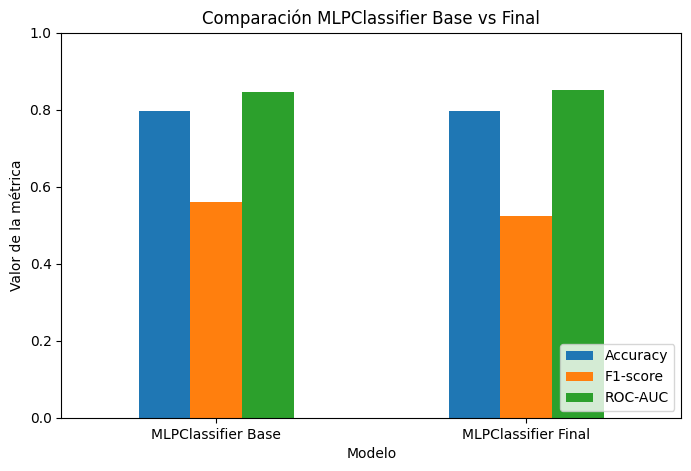

In [41]:
comparison_sklearn.set_index('Modelo')[
    ['Accuracy', 'F1-score', 'ROC-AUC']
].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Comparación MLPClassifier Base vs Final')
plt.ylabel('Valor de la métrica')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')

plt.figtext(
    0.5,
    -0.10,
    "",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

La comparación permite observar si el tuning realizado mejora el desempeño del modelo scikit-learn frente a su versión base

In [42]:
# GUARDAR MODELO FINAL

joblib.dump(
    mlp_final,
    'modelo_final/modelo_sklearn_final.pkl'
)

print("Modelo scikit-learn final guardado correctamente.")

Modelo scikit-learn final guardado correctamente.


# Conclusión del modelo scikit-learn

El modelo `MLPClassifier` permitió implementar una segunda red neuronal tipo perceptrón multicapa usando una librería diferente a Keras. La red fue entrenada con el mismo conjunto de datos preprocesados, lo que asegura una comparación justa entre ambos enfoques.

Además, se realizó un tuning básico de hiperparámetros, evaluando distintas arquitecturas, funciones de activación, regularización L2, learning rate y batch size. El modelo final fue seleccionado según el mayor ROC-AUC en validación.

Este notebook cumple con el requisito de implementar una red neuronal con una segunda librería y deja preparado el modelo para las comparaciones posteriores en el ablation study.